#  Slice wise registration

In [275]:
import re
import shutil
import subprocess

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from time import time
from PIL import Image

from nilearn.image import math_img
from nilearn.masking import apply_mask, unmask
from nipype.interfaces.ants import ApplyTransforms, Registration
from nipype.interfaces.fsl import FLIRT, FNIRT, ApplyWarp, InvWarp, ApplyXFM
from nipype.interfaces import afni
from scipy.ndimage import binary_fill_holes

from IPython.display import clear_output

from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

# Reportlab for pdf 

from reportlab.pdfbase import pdfmetrics
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas

In [2]:
# Reportlab params for reports

MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Bold.afm', '../../../utils/fonts/montserrat/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Light.afm', '../../../utils/fonts/montserrat/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(MontSerratBold)
montserrat_bold_name = 'Montserrat-Bold'

montserrat_bold_font = pdfmetrics.Font('Montserrat-Bold',
                           montserrat_bold_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_bold_font)

# Montserrat Light

pdfmetrics.registerTypeFace(MontSerratLight)
montserrat_light_name = 'Montserrat-Light'

montserrat_light_font = pdfmetrics.Font('Montserrat-Light',
                           montserrat_light_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_light_font)

In [272]:
############################################################################################################ 

############################################# FLIRT registration ###########################################

############################################################################################################

def compute_transform_flirt(
    file_name,
    ref_name,
    save_dir,
    prefix,
    suffix = 'pwd',
    in_weight = None,
    ref_weight = None,
    rigid_2D = None,
):

    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)
    
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.out_file = str(save_dir / f'{prefix}_{suffix}.nii.gz') 
    flt.inputs.out_matrix_file = str(save_dir / (prefix + '_registrationMatrix.mat'))
    if not (in_weight is None):
        flt.inputs.in_weight = str(in_weight)
    if not (ref_weight is None):
        flt.inputs.ref_weight = str(ref_weight)
    if not (rigid_2D is None):
        flt.inputs.rigid2D = rigid_2D
    print(flt.cmdline)
    res = flt.run()

    return str(save_dir / f'{prefix}_{suffix}.nii.gz'), str(save_dir / (prefix + '_registrationMatrix.mat'))

def apply_transform_flirt(
    file_name,
    ref_name,
    transformation_path,
    save_dir,
    prefix,
    suffix = 'pwd',
    interp = 'spline',
    rigid_2D = None,
):
    
    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)

    flt.inputs.apply_xfm = True
    flt.inputs.in_matrix_file = transformation_path
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.interp = interp
    flt.inputs.out_file = str(save_dir / f'{prefix}_{suffix}.nii.gz')
    
    if not (rigid_2D is None):
        flt.inputs.rigid2D = rigid_2D
    
    print(flt.cmdline)
    res = flt.run()

    return f'{prefix}.nii.gz'

############################################################################################################ 

############################################# FNIRT registration ###########################################

############################################################################################################

def compute_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    save_dir,
    prefix,
    suffix,
    affine_initialisation,
    refmask = None,
    inmask = None
):
    
    fnirt_mprage = FNIRT()
    fnirt_mprage.inputs.affine_file=affine_initialisation
    fnirt_mprage.inputs.in_file=file_blownup_name
    fnirt_mprage.inputs.ref_file=template_blownup_name
    fnirt_mprage.inputs.warped_file=str(save_dir / (prefix + '_' + suffix))

    # Params for angio
    
    # fnirt_mprage.inputs.in_fwhm = [8, 4, 2, 2]
    # fnirt_mprage.inputs.subsampling_scheme = [4, 2, 1, 1]
    # fnirt_mprage.inputs.regularization_lambda = [200, 75, 40, 20]

    # Params for 
    
    fnirt_mprage.inputs.in_fwhm = [4, 2, 2, 2]
    fnirt_mprage.inputs.subsampling_scheme = [2, 1, 1, 1]
    fnirt_mprage.inputs.regularization_lambda = [200, 100, 75, 50]
    fnirt_mprage.inputs.apply_intensity_mapping = [1, 1, 1, 1]
    fnirt_mprage.inputs.apply_refmask = [1, 1, 1, 1]
    fnirt_mprage.inputs.apply_inmask = [1, 1, 1, 1]
    
    if not (refmask is None):
        fnirt_mprage.inputs.refmask_file = refmask
    if not (inmask is None):
        fnirt_mprage.inputs.inmask_file = inmask
    
    fnirt_mprage.inputs.warp_resolution = (5,5,5)
    
    fnirt_mprage.cmdline

    fnirt_mprage.run()

    return str(save_dir / (prefix + '_' + suffix)), save_dir / (file_blownup_name.name.split('.nii.gz')[0] + '_warpcoef.nii.gz') 

def apply_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    transformation_path,
    save_dir,
    prefix,
    interp = 'trilinear'
):
    
    aw = ApplyWarp()
    aw.inputs.in_file = str(file_blownup_name)
    aw.inputs.ref_file = str(template_blownup_name)
    aw.inputs.field_file = str(transformation_path)
    aw.inputs.out_file = str(save_dir / (prefix + '.nii.gz'))
    aw.inputs.interp = interp

    aw.cmdline

    aw.run()

    return save_dir / (prefix + '.nii.gz')

############################################################################################################# 

############################################# ANTS registration #############################################

############################################################################################################# 

def compute_registration_ants(
    file_name, 
    ref_name, 
    output_dir, 
    registration_type = 'SyN', 
    fixed_mask = None,
    moving_mask = None,
    prefix= 'file_name',
    write_composite_transform = True,
    num_threads = 18,
    dimension = 2
):
    
    '''
    Performs registration using ants registration from nipype module

    file_name: (str)
    registration: (str)             Type of registration (either: Rigid, Affine or Syn) - performs a composition of them 
    '''
    
    reg = Registration()

    reg.inputs.fixed_image = str(ref_name)
    reg.inputs.moving_image = str(file_name)
    reg.inputs.dimension = dimension
    reg.inputs.initial_moving_transform_com = 1
    reg.inputs.write_composite_transform = write_composite_transform
    reg.inputs.collapse_output_transforms = False
    reg.inputs.num_threads = num_threads
    if not ((fixed_mask) is None) & ((moving_mask) is None):
        reg.inputs.args = f"--masks [{str(fixed_mask)},{str(moving_mask)}]"
    
    if registration_type == 'SyN':
        
        reg.inputs.output_transform_prefix = str(output_dir / f'{prefix}_')
        reg.inputs.transforms = ['Rigid', 'Affine', 'SyN']
        reg.inputs.transform_parameters = [(0.1,), (0.1,), (0.25, 3.0, 1.0)]
        reg.inputs.number_of_iterations = [[1000,500,250,100], [1500, 200], [100, 50, 30]]
        reg.inputs.smoothing_sigmas = [[3,2,1,0], [1,0], [4,2,1]]
        reg.inputs.shrink_factors = [[8,4,2,1], [2,1], [8,4,2]]
        reg.inputs.metric = ['MI', 'MI', 'MI']
        reg.inputs.radius_or_number_of_bins = [32, 32, 32]
        reg.inputs.metric_weight = [1]*3 # Default (value ignored currently by ANTs)
    
    elif registration_type == 'Affine':

        reg.inputs.output_transform_prefix = str(output_dir / f'{prefix}_')
        reg.inputs.transforms = ['Rigid', 'Affine']
        reg.inputs.transform_parameters = [(0.1,), (0.1,)]
        reg.inputs.number_of_iterations = [[1000,500,250,100], [1500, 200]]
        reg.inputs.smoothing_sigmas = [[3,2,1,0], [1,0]]
        reg.inputs.shrink_factors = [[8,4,2,1], [2,1]]
        reg.inputs.metric = ['MI', 'MI']
        reg.inputs.radius_or_number_of_bins = [32, 32]
        reg.inputs.metric_weight = [1]*2 # Default (value ignored currently by ANTs)
        
    elif registration_type == 'Rigid':
        
        reg.inputs.output_transform_prefix = str(output_dir / f'{prefix}_')
        reg.inputs.transforms = ['Rigid']
        reg.inputs.transform_parameters = [(0.1,)]
        reg.inputs.number_of_iterations = [[1000,500,250,100]]
        reg.inputs.smoothing_sigmas = [[3,2,1,0]]
        reg.inputs.shrink_factors = [[8,4,2,1]]
        reg.inputs.metric = ['MI']
        reg.inputs.radius_or_number_of_bins = [32]
        reg.inputs.metric_weight = [1] # Default (value ignored currently by ANTs)

    print(reg.cmdline)
    
    reg.run()
    
    return output_dir / f'{prefix}_Composite.h5'

def apply_transformation_ants(
    file_name, 
    ref_name, 
    transform_path,
    output_dir,
    prefix = 'registered_image',
    interpolation = 'Linear',
    invert_transform_flag = [False],
    dimension = 2
):
    
    """
    Apply a transformation computed by ANTsRegistration
    """
    
    at = ApplyTransforms()

    at.inputs.dimension = dimension
    at.inputs.input_image = str(file_name)
    at.inputs.reference_image = str(ref_name)
    at.inputs.output_image = str(output_dir / f'{prefix}.nii.gz')
    at.inputs.interpolation = interpolation
    at.inputs.default_value = 0
    at.inputs.transforms = str(transform_path)
    at.inputs.invert_transform_flags = invert_transform_flag

    at.cmdline
    
    at.run()
    
    return output_dir / f'{prefix}.nii.gz'

def apply_transformation_ants_sliceWise(
    local_img_data,
    slice_id,
    temp_dir,
    param_name
):
    
    local_slice_img = nib.Nifti1Image(
        local_img_data[:,:,:,slice_id],
        affine = local_affine
    )
    
    local_save_name = temp_dir / f'local_slice-{slice_id}.nii.gz'
    
    nib.save(
        local_slice_img,
        local_save_name
    )
    
    registered_slice_path = apply_transformation_ants(
        local_save_name,
        local_template_name, 
        param_name,
        temp_dir,
        prefix = f'local_slice-{slice_id}_registered',
        interpolation = 'Linear',
        invert_transform_flag = [False],
        dimension = 2
    )
    
    registered_slice = nib.load(registered_slice_path).get_fdata()
    
    local_save_name.unlink()
    registered_slice_path.unlink()
    
    return registered_slice

############################################################################################################# 

############################################### AFNI 3dAllineate ###########################################

############################################################################################################# 

def compute_registration_afni(
    file_name,
    template_name,
    save_dir,
    prefix,
    suffix,
    source_mask = None,
    target_mask = None
):

    allineate = afni.Allineate()
    allineate.inputs.in_file = file_name
    allineate.inputs.reference = template_name
    allineate.inputs.master = template_name
    allineate.inputs.out_file = str(save_dir / f'{prefix}_{suffix}') 
    # allineate.inputs.autoweight = "+10"
    allineate.inputs.center_of_mass = ""
    allineate.inputs.out_param_file = str(save_dir / f'{prefix}_warp.param.1D') 
    allineate.inputs.args = "-cost lpa"
    if not (source_mask is None):
        allineate.inputs.source_mask = source_mask
    if not (target_mask is None):
        allineate.inputs.weight = target_mask
    
    allineate.cmdline
    
    allineate.run()

    return save_dir / f'{prefix}_{suffix}', save_dir / f'{prefix}_warp.param.1D'

def apply_transform_afni(
    file_name,
    template_name,
    save_dir,
    prefix,
    param_name,
    interp = 'linear',
    quiet = None
):

    allineate = afni.Allineate()
    allineate.inputs.in_file = file_name
    allineate.inputs.out_file = template_name
    allineate.inputs.master = template_name
    allineate.inputs.in_param_file = param_name
    allineate.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    allineate.inputs.interpolation = interp
    if not (quiet is None):
        allineate.inputs.quiet = quiet
    
    print(allineate.cmdline)
    
    allineate.run()
    
    return save_dir / f'{prefix}.nii.gz'

############################################################################################################# 

################################################## AFNI Qwarp ###############################################

############################################################################################################# 

def compute_transform_qwarp(
    file_name,
    template_name,
    save_dir,
    prefix,
    suffix,
    source_mask = None,
    target_mask = None
):
    
    qwarp = afni.Qwarp()
    qwarp.inputs.in_file = file_name
    qwarp.inputs.base_file = template_name
    qwarp.inputs.out_file = str(save_dir / f'{prefix}_{suffix}') 
    qwarp.inputs.resample = True
    qwarp.inputs.lpa = True
    qwarp.inputs.iwarp = True
    qwarp.inputs.allineate = True
    qwarp.inputs.allineate_opts = "-com -cost lpa -autoweight +10"
    qwarp.inputs.blur = [0,-3]
    qwarp.inputs.minpatch = 10
    qwarp.inputs.num_threads = 18
    qwarp.inputs.quiet = True  
    if not (source_mask is None):
        qwarp.inputs.wmask = (str(source_mask), 1)
    if not (target_mask is None):
        qwarp.inputs.weight = str(target_mask)
    
    qwarp.cmdline

    qwarp.run()
    
    return str(save_dir / f'{prefix}_{suffix}') 


def apply_transform_qwarp(
    file_name,
    template_name,
    save_dir,
    prefix,
    transformation_path,
    interp = 'tri-linear'
):
    
    nwarp = afni.NwarpApply()
    nwarp.inputs.in_file = file_name
    nwarp.inputs.master = template_name
    nwarp.inputs.warp = str(transformation_path)
    nwarp.inputs.out_file = save_dir / f'{prefix}.nii.gz'
    nwarp.inputs.interp = interp
    nwarp.inputs.quiet = True
    nwarp.cmdline
    
    res = nwarp.run() 
    
    return save_dir / f'{prefix}.nii.gz'

###################################################### Utils

def clean_file(
    file_name,
    output_dir, 
    temp_dir
):

    target_folder = output_dir / file_name.parent.parent.name / file_name.parent.name 
    target_folder.mkdir(exist_ok = True, parents = True)

    for content_name in temp_dir.iterdir():

        target_name = target_folder / content_name.name
        shutil.move(content_name, target_name)
    
    return temp_dir

# Generate average Image

In [383]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
save_dir.mkdir(exist_ok = True, parents = True)

We found 212 files


In [11]:
for file_name in tqdm(root_dir):

    # average

    img = nib.load(file_name)
    img_slice = nib.Nifti1Image(
        img.get_fdata().mean(-1),
        affine = img.affine
    )
    
    # mask
    
    mask_slice = math_img("(a>0).astype('uint32')", a=img_slice)
    
    # dB
    
    logimg_data = np.log10(img_slice.get_fdata())
    logimg_data[np.isinf(logimg_data)] = 0
    logimg_data[np.isnan(logimg_data)] = 0
    logimg_slice = nib.Nifti1Image(
        logimg_data,
        affine = img_slice.affine
    )

    # saves
    
    save_name = save_dir / file_name.parent.parent.name / file_name.parent.name / "pwdAvg".join(file_name.name.split('pwd'))
    save_name.parent.mkdir(exist_ok = True, parents = True)
    nib.save(img_slice, save_name)
    save_name = save_dir / file_name.parent.parent.name / file_name.parent.name / "pwdMask".join(file_name.name.split('pwd'))
    nib.save(mask_slice, save_name)
    save_name = save_dir / file_name.parent.parent.name / file_name.parent.name / "pwddB".join(file_name.name.split('pwd'))
    nib.save(logimg_slice, save_name)

  0%|                                        | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_540074/3504844984.py:17: RuntimeWarning: divide by zero encountered in log10
  logimg_data = np.log10(img_slice.get_fdata())
100%|██████████████████████████████| 212/212 [02:30<00:00,  1.41it/s]


# dB

## FLIRT

In [398]:
mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/')
template_mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pwddB.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_FLIRT')
save_dir.mkdir(exist_ok = True, parents = True)

temp_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp')
temp_dir.mkdir(exist_ok = True, parents = True)

template_tag = 'pwddB'

We found 212 files


In [401]:
for file_name in tqdm(root_dir):

    img = nib.load(file_name)
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    prefix = file_name.name.split('_pwd')[0]
    suffix = file_name.name.split('_')[-1]
    
    mask_name = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*Mask.nii.gz$', x.name)])[0]
    
    if 'run' in file_name.name:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{run_id}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    else:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    
    template_mask_name = sorted([x for x in template_mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*{pose_id}.*.nii.gz$', x.name)])[0]
    
    print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}\n{mask_name.name}\n{template_name.name}\n{template_mask_name.name}')
    
    ####################################### Flipping files
    
    local_affine = np.diag([0.11,0.1,0.1,1.0])
    
    ############## Image
    
    local_img = nib.Nifti1Image(
        nib.load(file_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    local_img_name = temp_dir  / (prefix + 'Tranposed_pwd.nii.gz')
    nib.save(
        local_img,
        local_img_name
    )
    
    ############## template
    
    local_template_name = temp_dir  / (prefix + 'TranposedTemplate_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_name
    )
    
    ############## Mask
    
    local_mask_name = temp_dir  / (prefix + 'TranposedMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_mask_name
    )
    
    ############## Template Mask
    
    local_template_mask_name = temp_dir  / (prefix + 'TranposedTemplateMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_mask_name
    )
    
    ####################################### performs registration
    
    registered_path, transformation_path = compute_transform_flirt(
        local_img_name,
        local_template_name,
        temp_dir,
        prefix + 'TransposedSWFLIRT',
        suffix = 'pwddB',
        in_weight = local_mask_name,
        ref_weight = local_template_mask_name,
        rigid_2D = True
    )
    
    img_registered = nib.load(registered_path)
    
    ####################################### flips back
    
    img_out = nib.Nifti1Image(
        img_registered.get_fdata()[:,:,None].transpose([2,1,0]),
        affine = img.affine
    )
    
    nib.save(
        img_out,
        temp_dir / (prefix + 'SWFLIRT_' + suffix)
    )

    ####################################### cleans files

    clean_file(
        file_name,
        save_dir, 
        temp_dir
    )
        

  0%|                                        | 0/212 [00:00<?, ?it/s]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-0
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-0_feature.nii.gz
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstrTranposed_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstrTranposedTemplate_pwd.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328

  0%|▏                               | 1/212 [00:01<04:12,  1.20s/it]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-1
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-1_feature.nii.gz
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstrTranposed_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstrTranposedTemplate_pwd.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328

  1%|▎                               | 2/212 [00:02<04:03,  1.16s/it]

...

 99%|█████████████████████████████▋| 210/212 [03:55<00:02,  1.11s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-2
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-2_feature.nii.gz
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstrTranposed_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstrTranposedTemplate_pwd.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-c

100%|█████████████████████████████▊| 211/212 [03:56<00:01,  1.13s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-3
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-3_feature.nii.gz
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstrTranposed_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstrTranposedTemplate_pwd.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-c

100%|██████████████████████████████| 212/212 [03:57<00:00,  1.12s/it]


## ANTs Affine

In [429]:
mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/')
template_mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pwddB.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_ANTsAff')
save_dir.mkdir(exist_ok = True, parents = True)

temp_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp')
temp_dir.mkdir(exist_ok = True, parents = True)

template_tag = 'pwddB'

We found 212 files


In [441]:
for file_name in tqdm(root_dir):

    img = nib.load(file_name)

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    prefix = file_name.name.split('_pwd')[0]
    suffix = file_name.name.split('_')[-1]
    
    mask_name = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*Mask.nii.gz$', x.name)])[0]
    
    if 'run' in file_name.name:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{run_id}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    else:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    
    template_mask_name = sorted([x for x in template_mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*{pose_id}.*.nii.gz$', x.name)])[0]
    
    print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}\n{mask_name.name}\n{template_name.name}\n{template_mask_name.name}')
    
    ####################################### Flipping files in RSA 
    
    local_affine = np.diag([0.11,0.1,0.1,1.0])
    
    ############## Image
    
    local_img = nib.Nifti1Image(
        nib.load(file_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    local_img_name = temp_dir  / (prefix + 'Tranposed_pwd.nii.gz')
    nib.save(
        local_img,
        local_img_name
    )
    
    ############## template
    
    local_template_name = temp_dir  / (prefix + 'TranposedTemplate_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_name
    )
    
    ############## Mask
    
    local_mask_name = temp_dir  / (prefix + 'TranposedMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_mask_name
    )
    
    ############## Template Mask
    
    local_template_mask_name = temp_dir  / (prefix + 'TranposedTemplateMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_mask_name
    )
    
    ############## Compute Transform

    transform_path = compute_registration_ants(
        local_img_name, 
        local_template_name, 
        temp_dir, 
        registration_type = 'Affine', 
        fixed_mask=local_mask_name,
        moving_mask=local_template_mask_name, 
        prefix= prefix,
        write_composite_transform = True,
        num_threads = 18,
        dimension = 2
    )    
    
    ############## Apply Transform

    registered_path = apply_transformation_ants(
        local_img_name, 
        local_template_name, 
        transform_path,
        temp_dir,
        prefix = prefix + 'TransposedANTsAff',
        interpolation = 'Linear',
        invert_transform_flag = [False],
        dimension = 2
    )

    ####################################### flips back in PIRRAS

    img_registered = nib.load(registered_path)

    img_out = nib.Nifti1Image(
        img_registered.get_fdata()[:,:,None].transpose([2,1,0]),
        affine = img.affine
    )
    
    nib.save(
        img_out,
        temp_dir / (prefix + 'ANTsAff_' + suffix)
    )

    ####################################### cleans files
    
    clean_file(
        file_name,
        save_dir, 
        temp_dir
    )

  0%|                                        | 0/212 [00:00<?, ?it/s]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-0
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-0_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /media/DATA

  0%|▏                               | 1/212 [00:01<05:00,  1.42s/it]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-1
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-1_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /media/DATA

  1%|▎                               | 2/212 [00:02<04:52,  1.39s/it]

...

 99%|█████████████████████████████▋| 210/212 [05:22<00:03,  1.56s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-2
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-2_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /med

100%|█████████████████████████████▊| 211/212 [05:24<00:01,  1.56s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-3
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-3_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /med

100%|██████████████████████████████| 212/212 [05:25<00:00,  1.54s/it]


## ANTs SyN

In [442]:
mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/')
template_mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pwddB.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_ANTsSyN')
save_dir.mkdir(exist_ok = True, parents = True)

temp_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp')
temp_dir.mkdir(exist_ok = True, parents = True)

template_tag = 'pwddB'

We found 212 files


In [446]:
for file_name in tqdm(root_dir):

    img = nib.load(file_name)
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    prefix = file_name.name.split('_pwd')[0]
    suffix = file_name.name.split('_')[-1]
    
    mask_name = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*Mask.nii.gz$', x.name)])[0]
    
    if 'run' in file_name.name:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{run_id}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    else:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    
    template_mask_name = sorted([x for x in template_mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*{pose_id}.*.nii.gz$', x.name)])[0]
    
    print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}\n{mask_name.name}\n{template_name.name}\n{template_mask_name.name}')
    
    ####################################### Flipping files in RSA 
    
    local_affine = np.diag([0.11,0.1,0.1,1.0])
    
    ############## Image
    
    local_img = nib.Nifti1Image(
        nib.load(file_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    local_img_name = temp_dir  / (prefix + 'Tranposed_pwd.nii.gz')
    nib.save(
        local_img,
        local_img_name
    )
    
    ############## template
    
    local_template_name = temp_dir  / (prefix + 'TranposedTemplate_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_name
    )
    
    ############## Mask
    
    local_mask_name = temp_dir  / (prefix + 'TranposedMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_mask_name
    )
    
    ############## Template Mask
    
    local_template_mask_name = temp_dir  / (prefix + 'TranposedTemplateMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_mask_name
    )
    
    ############## Compute Transform

    transform_path = compute_registration_ants(
        local_img_name, 
        local_template_name, 
        temp_dir, 
        registration_type = 'SyN',  
        fixed_mask=local_mask_name,
        moving_mask=local_template_mask_name, 
        prefix= prefix,
        write_composite_transform = True,
        num_threads = 18,
        dimension = 2
    )    
    
    ############## Apply Transform

    registered_path = apply_transformation_ants(
        local_img_name, 
        local_template_name, 
        transform_path,
        temp_dir,
        prefix = prefix + 'TransposedANTsSyN',
        interpolation = 'Linear',
        invert_transform_flag = [False],
        dimension = 2
    )

    ####################################### flips back in PIRRAS

    img_registered = nib.load(registered_path)

    img_out = nib.Nifti1Image(
        img_registered.get_fdata()[:,:,None].transpose([2,1,0]),
        affine = img.affine
    )
    
    nib.save(
        img_out,
        temp_dir / (prefix + 'ANTsSyN_' + suffix)
    )

    ####################################### cleans files
    
    clean_file(
        file_name,
        save_dir, 
        temp_dir
    )

  0%|                                        | 0/212 [00:00<?, ?it/s]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-0
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-0_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /media/DATA

  0%|▏                               | 1/212 [00:01<06:27,  1.84s/it]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-1
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-1_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /media/DATA

  1%|▎                               | 2/212 [00:03<06:53,  1.97s/it]

...

 99%|█████████████████████████████▋| 210/212 [06:58<00:03,  1.99s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-2
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-2_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /med

100%|█████████████████████████████▊| 211/212 [07:00<00:01,  1.95s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-3
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-3_feature.nii.gz
antsRegistration --masks [/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstrTranposedMask_pwd.nii.gz,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstrTranposedTemplateMask_pwd.nii.gz] --collapse-output-transforms 0 --dimensionality 2 --initial-moving-transform [ /med

100%|██████████████████████████████| 212/212 [07:02<00:00,  1.99s/it]


## 3dAllineate

In [447]:
mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/')
template_mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pwddB.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_3dallineate')
save_dir.mkdir(exist_ok = True, parents = True)

temp_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp')
temp_dir.mkdir(exist_ok = True, parents = True)

template_tag = 'pwddB'

We found 212 files


In [453]:
for file_name in tqdm(root_dir):
    
    img = nib.load(file_name)

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    prefix = file_name.name.split('_pwd')[0]
    suffix = file_name.name.split('_')[-1]
    
    mask_name = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*Mask.nii.gz$', x.name)])[0]
    
    if 'run' in file_name.name:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{run_id}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    else:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    
    template_mask_name = sorted([x for x in template_mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*{pose_id}.*.nii.gz$', x.name)])[0]
    
    print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}\n{mask_name.name}\n{template_name.name}\n{template_mask_name.name}')
    
    ####################################### Flipping files in RSA 
    
    local_affine = np.diag([0.11,0.1,0.1,0.1])
    
    ############## Image
    
    local_img = nib.Nifti1Image(
        nib.load(file_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    local_img_name = temp_dir  / (prefix + 'Tranposed_pwd.nii.gz')
    nib.save(
        local_img,
        local_img_name
    )
    
    ############## template
    
    local_template_name = temp_dir  / (prefix + 'TranposedTemplate_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_name
    )
    
    ############## Mask
    
    local_mask_name = temp_dir  / (prefix + 'TranposedMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_mask_name
    )
    
    ############## Template Mask
    
    local_template_mask_name = temp_dir  / (prefix + 'TranposedTemplateMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_mask_name
    )

    ############## Registers
    
    registered_path, transformation_path = compute_registration_afni(
        local_img_name,
        local_template_name,
        temp_dir,
        prefix = prefix + 'Transposed3dAllineate',
        suffix = suffix,
        source_mask = local_mask_name,
        target_mask = local_template_mask_name
    )

    ####################################### flips back in PIRRAS
    
    img_registered = nib.load(registered_path)
    
    img_out = nib.Nifti1Image(
        img_registered.get_fdata()[:,:,None].transpose([2,1,0]),
        affine = img.affine
    )
    
    nib.save(
        img_out,
        temp_dir / (prefix + '3dAllineate_' + suffix)
    )

    ####################################### cleans files

    clean_file(
        file_name,
        save_dir, 
        temp_dir
    )

  0%|                                        | 0/212 [00:00<?, ?it/s]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-0
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-0_feature.nii.gz
250520-17:42:45,545 nipype.interface INFO:
	 stderr 2025-05-20T17:42:45.545333:++ 3dAllineate: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-17:42:45,546 nipype.interface INFO:
	 stderr 2025-05-20T17:42:45.545333:++ Authored by: Zhark the Registrator
250520-17:42:45,548 nipype.interface INFO:
	 stderr 2025-05-20T17:42:45.547963:++ Option '-cmass' enables center-of-mass code = 7 = +xyz
250520-17:42:45,548 nipype.interface INFO:
	 stderr 2025-05-20T17:42:45.547963:** AFNI converts NIFTI_datatype=64 (FL

  0%|▏                               | 1/212 [00:02<07:35,  2.16s/it]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-1
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-1_feature.nii.gz
250520-17:42:47,693 nipype.interface INFO:
	 stderr 2025-05-20T17:42:47.693708:++ 3dAllineate: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-17:42:47,694 nipype.interface INFO:
	 stderr 2025-05-20T17:42:47.693708:++ Authored by: Zhark the Registrator
250520-17:42:47,696 nipype.interface INFO:
	 stderr 2025-05-20T17:42:47.696179:++ Option '-cmass' enables center-of-mass code = 7 = +xyz
250520-17:42:47,697 nipype.interface INFO:
	 stderr 2025-05-20T17:42:47.696179:** AFNI converts NIFTI_datatype=64 (FL

  1%|▎                               | 2/212 [00:05<10:15,  2.93s/it]

...

 99%|█████████████████████████████▋| 210/212 [08:52<00:04,  2.49s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-2
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-2_feature.nii.gz
250520-17:51:37,727 nipype.interface INFO:
	 stderr 2025-05-20T17:51:37.727230:++ 3dAllineate: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-17:51:37,728 nipype.interface INFO:
	 stderr 2025-05-20T17:51:37.727230:++ Authored by: Zhark the Registrator
250520-17:51:37,729 nipype.interface INFO:
	 stderr 2025-05-20T17:51:37.729034:++ Option '-cmass' enables center-of-mass code = 7 = +xyz
250520-17:51:37,729 nipype.interface INFO:
	 stderr 2025-05-20T17:51:37.729034:** AFNI converts NIFTI_datatype=6

100%|█████████████████████████████▊| 211/212 [08:54<00:02,  2.49s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-3
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-3_feature.nii.gz
250520-17:51:40,200 nipype.interface INFO:
	 stderr 2025-05-20T17:51:40.200615:++ 3dAllineate: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-17:51:40,201 nipype.interface INFO:
	 stderr 2025-05-20T17:51:40.200615:++ Authored by: Zhark the Registrator
250520-17:51:40,202 nipype.interface INFO:
	 stderr 2025-05-20T17:51:40.202548:++ Option '-cmass' enables center-of-mass code = 7 = +xyz
250520-17:51:40,203 nipype.interface INFO:
	 stderr 2025-05-20T17:51:40.202548:** AFNI converts NIFTI_datatype=6

100%|██████████████████████████████| 212/212 [08:57<00:00,  2.53s/it]


## 3dQWarp

In [18]:
mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/')
template_mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pwddB.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_3dQWarp')
save_dir.mkdir(exist_ok = True, parents = True)

temp_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp')
temp_dir.mkdir(exist_ok = True, parents = True)

template_tag = 'pwddB'

We found 212 files


In [19]:
for file_name in tqdm(root_dir):
    
    img = nib.load(file_name)

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    prefix = file_name.name.split('_pwd')[0]
    suffix = file_name.name.split('_')[-1]
    
    mask_name = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{prefix}.*Mask.nii.gz$', x.name)])[0]
    
    if 'run' in file_name.name:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{run_id}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    else:
        template_name = sorted([x for x in mask_root.rglob('*') if x.is_file() and re.match(f'^{subject_name}.*{session_name}.*{pose_id}.*{template_tag}.nii.gz$', x.name)])[0]
    
    template_mask_name = sorted([x for x in template_mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*{pose_id}.*.nii.gz$', x.name)])[0]
    
    print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}\n{mask_name.name}\n{template_name.name}\n{template_mask_name.name}')
    
    
    ####################################### Flipping files in RSA 
    
    local_affine = np.diag([1.1,1.0,1.0,1.0])
    
    ############## Image
    
    local_img = nib.Nifti1Image(
        nib.load(file_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    local_img_name = temp_dir  / (prefix + 'Tranposed_pwd.nii.gz')
    nib.save(
        local_img,
        local_img_name
    )
    
    ############## template
    
    local_template_name = temp_dir  / (prefix + 'TranposedTemplate_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_name
    )
    
    ############## Mask
    
    local_mask_name = temp_dir  / (prefix + 'TranposedMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_mask_name
    )
    
    ############## Template Mask
    
    local_template_mask_name = temp_dir  / (prefix + 'TranposedTemplateMask_pwd.nii.gz')
    local_img = nib.Nifti1Image(
        nib.load(template_mask_name).get_fdata().transpose([2,1,0]),
        affine = local_affine
    )
    nib.save(
        local_img,
        local_template_mask_name
    )

    registered_path = compute_transform_qwarp(
        local_img_name,
        local_template_name,
        temp_dir,
        prefix,
        suffix,
        source_mask=None,
        target_mask=local_template_mask_name
    )

    ####################################### flips back in PIRRAS
    
    img_registered = nib.load(registered_path)
    
    img_out = nib.Nifti1Image(
        img_registered.get_fdata()[:,:,None].transpose([2,1,0]),
        affine = img.affine
    )
    
    nib.save(
        img_out,
        temp_dir / (prefix + '3dQwarp_' + suffix)
    )
    
    ####################################### cleans files
    
    clean_file(
        file_name,
        save_dir, 
        temp_dir
    )

  0%|                                        | 0/212 [00:00<?, ?it/s]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-0
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-0_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-0_feature.nii.gz
250520-18:55:22,654 nipype.interface INFO:
	 stderr 2025-05-20T18:55:22.654698:++ OpenMP thread count = 18
250520-18:55:22,655 nipype.interface INFO:
	 stderr 2025-05-20T18:55:22.655761:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-18:55:22,660 nipype.interface INFO:
	 stderr 2025-05-20T18:55:22.655761:++ Authored by: Zhark the (Hermite) Cubically Warped
250520-18:55:22,661 nipype.interface INFO:
	 stderr 2025-05-20T18:55:22.661193:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /med

  0%|▏                               | 1/212 [00:02<07:42,  2.19s/it]

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwddB.nii.gz
sub-cp230328a
ses-1CPTses1
pose-1
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-skstr_pwdMask.nii.gz
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-1_feature.nii.gz
250520-18:55:24,849 nipype.interface INFO:
	 stderr 2025-05-20T18:55:24.849319:++ OpenMP thread count = 18
250520-18:55:24,850 nipype.interface INFO:
	 stderr 2025-05-20T18:55:24.850510:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-18:55:24,851 nipype.interface INFO:
	 stderr 2025-05-20T18:55:24.850510:++ Authored by: Zhark the (Hermite) Cubically Warped
250520-18:55:24,852 nipype.interface INFO:
	 stderr 2025-05-20T18:55:24.850510:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /med

  1%|▎                               | 2/212 [00:04<07:52,  2.25s/it]

...

 99%|█████████████████████████████▋| 210/212 [08:03<00:04,  2.28s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-2
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-2_feature.nii.gz
250520-19:03:26,447 nipype.interface INFO:
	 stderr 2025-05-20T19:03:26.447752:++ OpenMP thread count = 18
250520-19:03:26,448 nipype.interface INFO:
	 stderr 2025-05-20T19:03:26.448813:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-19:03:26,449 nipype.interface INFO:
	 stderr 2025-05-20T19:03:26.448813:++ Authored by: Zhark the (Hermite) Cubically Warped
250520-19:03:26,450 nipype.interface INFO:
	 stderr 2025-05-20T19:03:26.450293:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file

100%|█████████████████████████████▊| 211/212 [08:06<00:02,  2.28s/it]

sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwddB.nii.gz
sub-cp230515b
ses-1CPTses11
pose-3
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-skstr_pwdMask.nii.gz
sub-cp230515b_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-3_proc-registered_pwddB.nii.gz
source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-3_feature.nii.gz
250520-19:03:28,712 nipype.interface INFO:
	 stderr 2025-05-20T19:03:28.712497:++ OpenMP thread count = 18
250520-19:03:28,713 nipype.interface INFO:
	 stderr 2025-05-20T19:03:28.713870:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250520-19:03:28,714 nipype.interface INFO:
	 stderr 2025-05-20T19:03:28.713870:++ Authored by: Zhark the (Hermite) Cubically Warped
250520-19:03:28,715 nipype.interface INFO:
	 stderr 2025-05-20T19:03:28.715339:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file

100%|██████████████████████████████| 212/212 [08:08<00:00,  2.30s/it]


# QC

In [21]:
template_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

mask_roots = [
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_3dallineate/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_3dQWarp/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_ANTsAff/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_ANTsSyN/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_FLIRT/')
]

filters = [
    '3dAllineate',
    '3dQwarp',
    'ANTsAff',
    'ANTsSyN',
    'SWFLIRT'
]

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/00_avg-slice')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pwddB.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/QCs')
save_dir.mkdir(exist_ok = True, parents = True)

We found 212 files


## Images

In [22]:
for file_name in tqdm(root_dir):

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    else:
        run_id = 'run-none'
    
    # print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{run_id}')

    for local_root, local_filter in zip(mask_roots, filters):
        
        if 'run' in file_name.name:
            regex = f'^.*{subject_name}.*{session_name}.*{run_id}.*{pose_id}.*{local_filter}_pwddB.nii.gz$'
        else:
            regex = f'^.*{subject_name}.*{session_name}.*{pose_id}.*{local_filter}_pwddB.nii.gz$'
        
        registered_img = sorted([x for x in local_root.rglob('*') if x.is_file() and re.match(regex, x.name)])[0]
        
        img = nib.load(registered_img)
        
        local_template_name = sorted([x for x in template_root.iterdir() if x.is_file() and re.match(f'^.*desc-dBGillianTemplate.*{pose_id}.*.nii.gz$', x.name)])[0]
        local_mask_name = sorted([x for x in template_root.iterdir() if x.is_file() and re.match(f'^.*desc-AllenMask.*{pose_id}.*.nii.gz$', x.name)])[0]
        
        local_template_img = nib.load(local_template_name)
        local_mask_img = nib.load(local_mask_name)

        prefix = registered_img.name.split('pwddB')[0]

        # target folder

        target_folder = save_dir / subject_name / session_name 
        target_folder.mkdir(exist_ok = True, parents = True)

        ################### Registered Image
        
        fig, ax = plt.subplots(1,1,figsize = (7,5), dpi = 200, facecolor = 'k')
        
        ax.imshow(img.get_fdata().squeeze(), cmap = cc.cm['fire'], vmin = 0.7, vmax = 1.7, aspect = 0.1/0.11)
        ax.axis('off')
        
        plt.tight_layout()

        save_name = target_folder / f'{prefix}visualRegistered.png'
        plt.savefig(save_name)
        plt.close('all')

        ################### Mask Overlay

        fig, ax = plt.subplots(1,1,figsize = (7,5), dpi = 200, facecolor = 'k')
        
        img_2_display = local_template_img.get_fdata().squeeze()
        ax.imshow(img_2_display, aspect = 0.1/0.11, cmap = 'Greys_r', vmin = 0.8, vmax = 2.2)
        ax.axis('off')
        
        img_2_display = img.get_fdata().squeeze()
        ax.imshow(img_2_display, aspect = 0.1/0.11, cmap = cc.cm['fire'], vmin = 0.7, vmax = 1.7, alpha = 0.5)
        ax.axis('off')
        
        img_2_display = local_mask_img.get_fdata().squeeze()
        ax.imshow(img_2_display, aspect = 0.1/0.11, cmap = 'Greys_r', vmin = 0., vmax = 1., alpha = 0.3*(img_2_display>0))
        ax.axis('off')
        
        plt.tight_layout()

        save_name = target_folder / f'{prefix}visualMaskOverlay.png'
        plt.savefig(save_name)
        plt.close('all')
        
        ################### Images Overlay

        fig, ax = plt.subplots(1,1,figsize = (7,5), dpi = 200, facecolor = 'k')

        img_2_display = (local_template_img.get_fdata()-0.8)/(2.2-0.8)
        img_2_display[(img_2_display < 0)] = 0 
        img_2_display[(img_2_display > 1)] = 1
        img_2_display = np.concatenate([img_2_display, np.zeros(img_2_display.shape), img_2_display]).transpose(1,2,0)
        
        ax.imshow(img_2_display, aspect = 0.1/0.11)
        ax.axis('off')
        
        img_2_display = (img.get_fdata()-0.7)/(1.7-0.7)
        img_2_display[(img_2_display < 0)] = 0 
        img_2_display[(img_2_display > 1)] = 1
        img_2_display = np.concatenate([np.zeros(img_2_display.shape), img_2_display, np.zeros(img_2_display.shape)]).transpose(1,2,0)
        
        ax.imshow(img_2_display, aspect = 0.1/0.11, alpha = 0.5)
        ax.axis('off')
        
        plt.tight_layout()

        save_name = target_folder / f'{prefix}visualImageOverlay.png'
        plt.savefig(save_name)
        plt.close('all')

100%|██████████████████████████████| 212/212 [31:41<00:00,  8.97s/it]


## Report

In [23]:
root_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/QCs')

file_name_df = {}

for tag in ['3dAllineate', '3dQwarp', 'ANTsAff', 'ANTsSyN', 'FLIRT']:

    file_name_df[tag] = {}

    for img_type in ['visualRegistered', 'visualMaskOverlay', 'visualImageOverlay']:
    
        file_name_df[tag][img_type] = sorted([x for x in root_dir.rglob('*') if x.is_file() and re.match(f'^.*{tag}.*{img_type}.png$', x.name)])

In [24]:
for tag in ['3dAllineate', '3dQwarp', 'ANTsAff', 'ANTsSyN', 'FLIRT']:

    for img_type in ['visualRegistered', 'visualMaskOverlay', 'visualImageOverlay']:

        print(len(file_name_df[tag][img_type]))

212
212
212
212
212
212
212
212
212
212
212
212
212
212
212


In [25]:
w,h = [1300, 1350]

# starts

c = canvas.Canvas(str(root_dir / "SWRegistration_report.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - Slicewise Registration'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

for i in tqdm(range(len(file_name_df['3dAllineate']['visualRegistered']))):    
        
    file_name = file_name_df['3dAllineate']['visualRegistered'][i]

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        file_title = f'{subject_name} {session_name} {run_id} {pose_id}'
    else:
        file_title = f'{subject_name} {session_name} {pose_id}'
            
    ########################### Sets page layout
    
    # set background
    
    c.setFillColorRGB(0,0,0)
    c.rect(0,0,w,h,fill=1)
    
    current_alt = h
    
    # title
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 25)
    c.drawString(10, h-50, file_title)

    # legends

    for j,tag in enumerate(['3dAllineate', '3dQwarp', 'ANTsAff', 'ANTsSyN', 'FLIRT']):
    
        c.setFillColorRGB(1,1,1)
        c.setFont("Montserrat-Light", 20)
        c.drawString(50, h-(225+j*250), tag)
    
    # ########################### Displays slices
    
    for j,tag in enumerate(['3dAllineate', '3dQwarp', 'ANTsAff', 'ANTsSyN', 'FLIRT']):

        for k,img_type in enumerate(['visualRegistered', 'visualMaskOverlay', 'visualImageOverlay']):
   
            img = ImageReader(file_name_df[tag][img_type][i])
            img_w, img_h = img.getSize()
            c.drawImage(img, 200+(k*(1400/4)), h-(100+(j+1)*250), width=img_w/4, height = img_h/4)
    
    c.showPage() 
        
c.save()   



100%|██████████████████████████████| 212/212 [03:58<00:00,  1.12s/it]


## Selection file

In [27]:
data_dict = {
    'file_name':[],
    'subject':[],
    'session':[],
    'pose':[],
    'run':[],
    'Allineate':[],
    'Qwarp':[],
    'ANTs-Aff':[],
    'ANTs-SyN':[],
    'FLIRT':[]
}

for i in (range(len(file_name_df['3dAllineate']['visualRegistered']))):    
        
    file_name = file_name_df['3dAllineate']['visualRegistered'][i]

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    else:
        run_id = ''

    data_dict['file_name'].append(file_name.name)
    data_dict['subject'].append(subject_name)
    data_dict['session'].append(session_name)
    data_dict['pose'].append(pose_id)
    data_dict['run'].append(run_id)
    data_dict['ANTs-Aff'].append(-1)
    data_dict['ANTs-SyN'].append(-1)
    data_dict['FLIRT'].append(-1)
    data_dict['Allineate'].append(-1)
    data_dict['Qwarp'].append(-1)

csv_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/selection_slice-wise_empty.csv')

df = pd.DataFrame(data_dict)

df.to_csv(csv_name)    

In [ ]:
for file_name in root_dir:

    print(file_name.name)

data_dict = {
    'file_name':[],
    'subject':[],
    'session':[],
    'pose':[],
    'run':[],
    'Allineate':[],
    'Qwarp':[],
    'ANTs-Aff':[],
    'ANTs-SyN':[],
    'FLIRT':[]
}

for file_name in root_dir:
   
    data_dict['file_name'].append(file_name.name)
    data_dict['subject'].append(subject_name)
    data_dict['session'].append(session_name)
    data_dict['pose'].append(pose_id)
    data_dict['run'].append(run_id)
    data_dict['ANTs-Aff'].append(-1)
    data_dict['ANTs-SyN'].append(-1)
    data_dict['FLIRT'].append(-1)
    data_dict['Allineate'].append(-1)
    data_dict['Qwarp'].append(-1)
    
csv_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/selection_slice-wise_empty.csv')

df = pd.DataFrame(data_dict)

df.to_csv(csv_name)

# Select + Apply transform

In [381]:
csv_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/selection_slice-wise_full.csv')
param_dict = pd.read_csv(csv_name)
param_dict.head(5)

,Unnamed: 0,file_name,subject,session,pose,run,Allineate,Qwarp,ANTs-Aff,ANTs-SyN,FLIRT
0,0,sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...,sub-cp230328a,ses-1CPTses1,pose-0,NaN,0,0,2,3,2
1,1,sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...,sub-cp230328a,ses-1CPTses1,pose-1,NaN,2,0,3,2,2
2,2,sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...,sub-cp230328a,ses-1CPTses1,pose-2,NaN,2,1,3,2,2
3,3,sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...,sub-cp230328a,ses-1CPTses1,pose-3,NaN,2,0,3,2,2
4,4,sub-cp230328b_ses-1CPTses1_task-rest_acq-3Dfus...,sub-cp230328b,ses-1CPTses1,pose-0,NaN,0,0,0,0,3


In [382]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')
mask_roots = np.array([
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_3dallineate/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_3dQWarp/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_ANTsAff/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_ANTsSyN/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered_FLIRT/')
])

parameter_file = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/selection_slice-wise_full.csv')
pipe_df = pd.read_csv(parameter_file)


pipe_names = [
    'Allineate',
    'Qwarp',
    'ANTs-Aff',
    'ANTs-SyN',
    'FLIRT',
]

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dfus.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered/')

temp_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/')

t_r = 2.4

print(pipe_df.head(5))

We found 212 files
   Unnamed: 0                                          file_name  \
0           0  sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...   
1           1  sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...   
2           2  sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...   
3           3  sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...   
4           4  sub-cp230328b_ses-1CPTses1_task-rest_acq-3Dfus...   

         subject       session    pose  run  Allineate  Qwarp  ANTs-Aff  \
0  sub-cp230328a  ses-1CPTses1  pose-0  NaN          0      0         2   
1  sub-cp230328a  ses-1CPTses1  pose-1  NaN          2      0         3   
2  sub-cp230328a  ses-1CPTses1  pose-2  NaN          2      1         3   
3  sub-cp230328a  ses-1CPTses1  pose-3  NaN          2      0         3   
4  sub-cp230328b  ses-1CPTses1  pose-0  NaN          0      0         0   

   ANTs-SyN  FLIRT  
0         3      2  
1         2      2  
2         2      2  
3         2      2  
4         0     

Best performing Pipeline:


FLIRT          : 91.98
ANTs-Aff       : 69.34
Allineate      : 66.98
ANTs-SyN       : 65.09
Qwarp          : 0.00


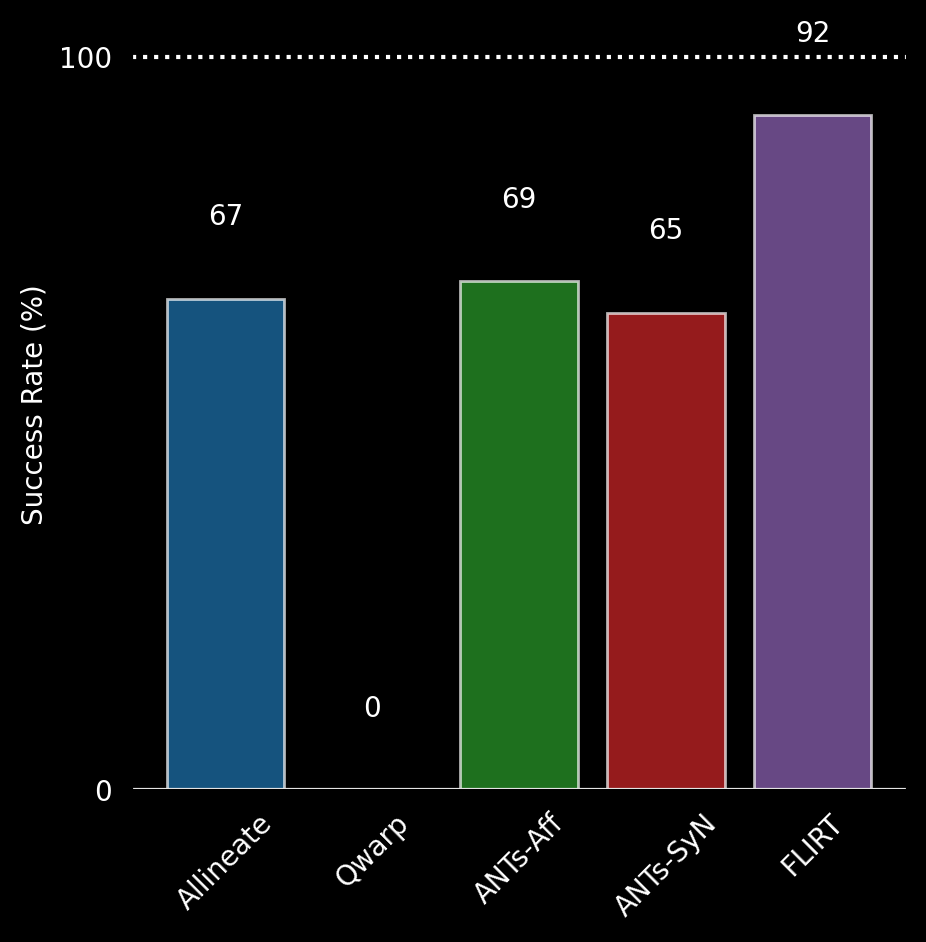

In [383]:
fig, ax = plt.subplots(1,1,figsize = (5,5), dpi = 200, facecolor = 'k')

ax.set(facecolor = 'k')

success_rate = []

for i, pipe_name in enumerate(pipe_names):

    score = 100*(pipe_df[pipe_name] >= 2).sum()/len(pipe_df)
    success_rate.append(score)
    
    ax.bar(i, score, alpha = 0.7, edgecolor = 'w')

    ax.text(i, score + 10, f'{score:.0f}', c = 'w', horizontalalignment = 'center')
    
plt.xticks(np.arange(len(pipe_names)), pipe_names, c = 'w', rotation = 45)

plt.axhline(0, c = 'w')
plt.axhline(100, c = 'w', ls = ':')

plt.yticks([0,100], [0,100], color = 'w')
plt.ylabel('Success Rate (%)', color = 'w')

best_performing = np.array(pipe_names)[np.flip(np.argsort(success_rate).squeeze())]

print('Best performing Pipeline:\n\n')

for x,score in zip(best_performing, np.array(success_rate)[np.flip(np.argsort(success_rate).squeeze())]):

    print(f'{x:<15}: {score:.2f}')

## Loop 

In [396]:
file_id = 148

file_name = root_dir[file_id]

In [399]:
for file_name in tqdm(root_dir):
    
    with open(log_name, 'w') as f:
    
        print(file_name.name)
        f.write(f'{file_name.name}\n\n')
        
        img = nib.load(file_name)
        
        # Extracts file properties
        
        subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
        session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
        pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
        
        if 'run' in file_name.name:
            run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
            title = f'{subject_name} {session_name} {pose_id} {run_id}'
            regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*{run_id}.*'
        else: 
            run_id = None
            title = f'{subject_name} {session_name} {pose_id}'
            regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*'
    
        f.write(f'\t{title}\n')
        
        # Selects best performing algorithm
        
        if 'run' in file_name.name:
            pipe_scores = [pipe_df[(pipe_df['subject'] == subject_name) & (pipe_df['session'] == session_name) & (pipe_df['pose'] == pose_id) & (pipe_df['run'] == run_id)][pipe_name].values[0] for pipe_name in pipe_names]
        else:
            pipe_scores = [pipe_df[(pipe_df['subject'] == subject_name) & (pipe_df['session'] == session_name) & (pipe_df['pose'] == pose_id)][pipe_name].values[0] for pipe_name in pipe_names]
        
        ######################################################### Failed registration
        
        if np.max(pipe_scores) == 0:
        
            print('No pipeline worked for this file')
            
            f.write(f'\tNo pipeline worked for this file\n\n')
        
        ######################################################### Finds adequate pipeline
        
        else:
        
            if (pipe_scores == np.max(pipe_scores)).sum() == 1:
        
                source_idx = np.argmax(pipe_scores).squeeze()
        
            else:
            
                ind = np.argwhere(pipe_scores == np.max(pipe_scores)).squeeze()
                ind_pipe = np.argmax(np.array(success_rate)[ind]).squeeze()
                source_idx = ind[ind_pipe]
        
            analysis_id = source_idx
            
            print(mask_roots[analysis_id])
            
            f.write(f'\t{pipe_scores}\n\t{mask_roots[analysis_id]}\n')
        
            ################################################################################################################################
            
            ######################################################### 3D Allineate #########################################################
        
            ################################################################################################################################
            
            if analysis_id == 0:
    
                f.write(f'\t3D Alineate\n\n')
        
                subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
                session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
                pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
                if 'run' in file_name.name:
                    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
                
                prefix = file_name.name.split('_pwd')[0]
                suffix = file_name.name.split('_')[-1]
                
                
                
                print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')
                
                ####################################### Reorienting in abstract transformation space 
                
                local_affine = np.diag([0.11,0.1,0.1,0.1])
                
                ############## Image
                
                local_img = nib.Nifti1Image(
                    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
                    affine = local_affine
                )
                
                local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
                nib.save(
                    local_img,
                    local_img_name
                )
                
                ####################################### loads the parameters
                
                if 'run' in file_name.name:
                    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
                else:
                    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'
                
                param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*warp.param.1D$', x.name)])[0]
                
                local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]
                
                ####################################### Apply the transform
                
                local_registered_path = apply_transform_afni(
                    local_img_name,
                    local_template_name,
                    temp_dir,
                    prefix + '_proc-TransposedRegistered3dAllineate',
                    param_name,
                    interp = 'linear',
                    quiet = True
                )
                
                ####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking
                
                local_mask_img = nib.Nifti1Image(
                    slice_mask_datas[int(pose_id[-1])],
                    affine = new_affine
                )
                
                img_out = nib.Nifti1Image(
                    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
                    affine = new_affine
                )
                
                # img_out = unmask(
                #     apply_mask(
                #         img_out,
                #         local_mask_img
                #     ),
                #     local_mask_img
                # )
                
                img_out.header.set_zooms((0.11,0.1,0.1,t_r))
                img_out.header['xyzt_units'] = 10
                img_out.header['cal_min'] = 0
                img_out.header['cal_max'] = 80
                
                ####################################### Saving result and cleaning temp dir
                
                save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregistered_pwd.nii.gz'
                save_name.parent.mkdir(parents = True, exist_ok = True)
                
                nib.save(
                    img_out,
                    save_name
                )
                
                # Clean temp dir
                
                for x in temp_dir.iterdir():
                    if x.is_file():
                        x.unlink()
                
                clear_output(wait = True)
            
            ################################################################################################################################
            
            ########################################################### 3D Qwarp ###########################################################
        
            ################################################################################################################################
            
            elif analysis_id == 1:
    
                f.write(f'\t3D QWarp\n\n')
        
                subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
                session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
                pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
                if 'run' in file_name.name:
                    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
                
                prefix = file_name.name.split('_pwd')[0]
                suffix = file_name.name.split('_')[-1]
                
                
                
                print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')
                
                ####################################### Reorienting in abstract transformation space 
                
                local_affine = np.diag([1.1,1.0,1.0,1.0])
                
                ############## Image
                
                local_img = nib.Nifti1Image(
                    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
                    affine = local_affine
                )
                
                local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
                nib.save(
                    local_img,
                    local_img_name
                )
                
                ####################################### loads the parameters
                
                if 'run' in file_name.name:
                    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
                else:
                    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'
                
                param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*WARP.nii.gz$', x.name)])[0]
                
                local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]
                
                local_registered_path = apply_transform_qwarp(
                    local_img_name,
                    local_template_name,
                    temp_dir,
                    prefix + '_proc-TransposedRegistered3dQwarp',
                    param_name,
                    interp = 'trilinear'
                )
                
                ####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking
                
                local_mask_img = nib.Nifti1Image(
                    slice_mask_datas[int(pose_id[-1])],
                    affine = new_affine
                )
                
                img_out = nib.Nifti1Image(
                    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
                    affine = new_affine
                )
                
                # img_out = unmask(
                #     apply_mask(
                #         img_out,
                #         local_mask_img
                #     ),
                #     local_mask_img
                # )
                
                img_out.header.set_zooms((0.11,0.1,0.1,t_r))
                img_out.header['xyzt_units'] = 10
                img_out.header['cal_min'] = 0
                img_out.header['cal_max'] = 80
                
                ####################################### Saving result and cleaning temp dir
                
                save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregistered_pwd.nii.gz'
                save_name.parent.mkdir(parents = True, exist_ok = True)
                
                nib.save(
                    img_out,
                    save_name
                )
                
                # Clean temp dir
                
                for x in temp_dir.iterdir():
                    if x.is_file():
                        x.unlink()
                
                clear_output(wait = True)
            
            ################################################################################################################################
            
            ########################################################## ANTs Affine #########################################################
        
            ################################################################################################################################
            
            elif analysis_id == 2:
    
                f.write(f'\tANTs Affine\n\n')
        
                subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
                session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
                pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
                if 'run' in file_name.name:
                    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
                
                prefix = file_name.name.split('_pwd')[0]
                suffix = file_name.name.split('_')[-1]
                
                print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')
                
                ####################################### Reorienting in abstract transformation space 
                
                local_affine = np.diag([0.11,0.1,0.1,1.0])
                
                ############## Image
                
                local_img = nib.Nifti1Image(
                    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
                    affine = local_affine
                )
                
                local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
                nib.save(
                    local_img,
                    local_img_name
                )
    
                local_img_data = local_img.get_fdata()
                
                ####################################### loads the parameters
                
                if 'run' in file_name.name:
                    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
                else:
                    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'
                
                param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*Composite.h5$', x.name)])[0]
                
                local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]
                
                # fast
                
                with tqdm_joblib(desc=f"Registering slice wise", total=local_img_data.shape[-1]) as progress_bar:
                
                    registered_list = Parallel(n_jobs=16)(delayed(apply_transformation_ants_sliceWise)(
                        local_img_data,
                        slice_id,
                        temp_dir,
                        param_name
                    ) for slice_id in range(local_img_data.shape[-1]))
                
                
                
                local_registered_path = temp_dir / f'{prefix}_proc-TransposedRegisteredANTsAffine_pwd.nii.gz'
                
                nib.save(
                    nib.Nifti1Image(
                        np.array(registered_list).transpose([1,2,0])[:,:,None,:],
                        affine = local_affine
                    ),
                    local_registered_path
                )
                
                ####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking
                
                local_mask_img = nib.Nifti1Image(
                    slice_mask_datas[int(pose_id[-1])],
                    affine = new_affine
                )
                
                img_out = nib.Nifti1Image(
                    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
                    affine = new_affine
                )
                
                # img_out = unmask(
                #     apply_mask(
                #         img_out,
                #         local_mask_img
                #     ),
                #     local_mask_img
                # )
                
                img_out.header.set_zooms((0.11,0.1,0.1,t_r))
                img_out.header['xyzt_units'] = 10
                img_out.header['cal_min'] = 0
                img_out.header['cal_max'] = 80
                
                ####################################### Saving result and cleaning temp dir
                
                save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregistered_pwd.nii.gz'
                save_name.parent.mkdir(parents = True, exist_ok = True)
                
                nib.save(
                    img_out,
                    save_name
                )
                
                # Clean temp dir
                
                for x in temp_dir.iterdir():
                    if x.is_file():
                        x.unlink()
                
                clear_output(wait = True)
            
            ################################################################################################################################
            
            ########################################################### ANTs SyN ###########################################################
        
            ################################################################################################################################
            
            elif analysis_id == 3:
    
                f.write(f'\tANTs SyN\n\n')
        
                subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
                session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
                pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
                if 'run' in file_name.name:
                    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
                
                prefix = file_name.name.split('_pwd')[0]
                suffix = file_name.name.split('_')[-1]
                
                print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')
                
                ####################################### Reorienting in abstract transformation space 
                
                local_affine = np.diag([0.11,0.1,0.1,1.0])
                
                ############## Image
                
                local_img = nib.Nifti1Image(
                    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
                    affine = local_affine
                )
                
                local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
                nib.save(
                    local_img,
                    local_img_name
                )
    
                local_img_data = local_img.get_fdata()
                
                ####################################### loads the parameters
                
                if 'run' in file_name.name:
                    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
                else:
                    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'
                
                param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*Composite.h5$', x.name)])[0]
                
                local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]
                
                # fast
                
                with tqdm_joblib(desc=f"Registering slice wise", total=local_img_data.shape[-1]) as progress_bar:
                
                    registered_list = Parallel(n_jobs=16)(delayed(apply_transformation_ants_sliceWise)(
                        local_img_data,
                        slice_id,
                        temp_dir,
                        param_name
                    ) for slice_id in range(local_img_data.shape[-1]))
                
                
                
                local_registered_path = temp_dir / f'{prefix}_proc-TransposedRegisteredANTsSyN_pwd.nii.gz'
                
                nib.save(
                    nib.Nifti1Image(
                        np.array(registered_list).transpose([1,2,0])[:,:,None,:],
                        affine = local_affine
                    ),
                    local_registered_path
                )
                
                ####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking
                
                local_mask_img = nib.Nifti1Image(
                    slice_mask_datas[int(pose_id[-1])],
                    affine = new_affine
                )
                
                img_out = nib.Nifti1Image(
                    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
                    affine = new_affine
                )
                
                # img_out = unmask(
                #     apply_mask(
                #         img_out,
                #         local_mask_img
                #     ),
                #     local_mask_img
                # )
                
                img_out.header.set_zooms((0.11,0.1,0.1,t_r))
                img_out.header['xyzt_units'] = 10
                img_out.header['cal_min'] = 0
                img_out.header['cal_max'] = 80
                
                ####################################### Saving result and cleaning temp dir
                
                save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregistered_pwd.nii.gz'
                save_name.parent.mkdir(parents = True, exist_ok = True)
                
                nib.save(
                    img_out,
                    save_name
                )
                
                # Clean temp dir
                
                for x in temp_dir.iterdir():
                    if x.is_file():
                        x.unlink()
                
                clear_output(wait = True)
            
            ################################################################################################################################
            
            ############################################################ FLIRT ############################################################
        
            ################################################################################################################################
            
            elif analysis_id == 4:
    
                f.write(f'\tFLIRT\n\n')
        
                subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
                session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
                pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
                if 'run' in file_name.name:
                    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
                
                prefix = file_name.name.split('_pwd')[0]
                suffix = file_name.name.split('_')[-1]
                
                print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')
                
                ####################################### Reorienting in abstract transformation space 
                
                local_affine = np.diag([0.11,0.1,0.1,1.0])
                
                ############## Image
                
                local_img = nib.Nifti1Image(
                    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
                    affine = local_affine
                )
                
                local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
                nib.save(
                    local_img,
                    local_img_name
                )
                
                ####################################### loads the parameters
                
                if 'run' in file_name.name:
                    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
                else:
                    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'
                
                param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*registrationMatrix.mat$', x.name)])[0]
                
                local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]
                
                local_registered_path = temp_dir / f"{prefix}_proc-TransposedRegisteredFLIRT_{suffix}.nii.gz"
                
                # Applies the transform
                
                cmd = [
                    'flirt',
                    '-in', str(local_img_name),
                    '-ref', str(local_template_name),
                    '-out', str(local_registered_path),
                    '-init', str(param_name), 
                    '-applyxfm',
                    '-2D'
                ]
                
                _ = subprocess.run(
                    cmd
                )
                
                ####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking
                
                local_mask_img = nib.Nifti1Image(
                    slice_mask_datas[int(pose_id[-1])],
                    affine = new_affine
                )
                
                img_out = nib.Nifti1Image(
                    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
                    affine = new_affine
                )
                
                # img_out = unmask(
                #     apply_mask(
                #         img_out,
                #         local_mask_img
                #     ),
                #     local_mask_img
                # )
                
                img_out.header.set_zooms((0.11,0.1,0.1,t_r))
                img_out.header['xyzt_units'] = 10
                img_out.header['cal_min'] = 0
                img_out.header['cal_max'] = 80
                
                ####################################### Saving result and cleaning temp dir
                
                save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregistered_pwd.nii.gz'
                save_name.parent.mkdir(parents = True, exist_ok = True)
                
                nib.save(
                    img_out,
                    save_name
                )
                
                # Clean temp dir
                
                for x in temp_dir.iterdir():
                    if x.is_file():
                        x.unlink()
                
                clear_output(wait = True)

yolo


## QC

### Images

In [445]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered/')

mask_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')
mask_dir = sorted([x for x in mask_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*pose-(0|1|2|3).*.nii.gz$', x.name)])
slice_masks = [nib.load(x) for x in mask_dir]

template_dir = sorted([x for x in mask_root.iterdir() if x.is_file() and re.match(f'^.*desc-GillianTemplate.*pose-(0|1|2|3).*.nii.gz$', x.name)])
slice_templates = [nib.load(x) for x in template_dir]

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*proc-choppedSWregistered.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/rawdata/')
save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/QCs_final/')

t_r = 2.4

We found 210 files


In [464]:
for file_name in tqdm(root_dir):
    
    ###### Gets file features
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    pose_idx = int(pose_id[-1])
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    
    prefix = file_name.name.split('_pwd')[0]
    suffix = file_name.name.split('_')[-1]
    
    ###### Loads data + Masks data
    
    img = nib.load(file_name)
    masked_img = unmask(apply_mask(img, slice_masks[pose_idx]), slice_masks[pose_idx])
    
    ###### Display
    
    ################################################################################### Registered Data
    
    plt.figure(figsize = (7,5), dpi = 200, facecolor = 'k')
    
    img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
    img_2_display[np.isnan(img_2_display) | np.isinf(img_2_display)] = 0
    plt.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)
    plt.axis('off')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / subject_name / session_name / f'{prefix}_registeredImg.png'
    save_name.parent.mkdir(parents = True, exist_ok = True)
    plt.savefig(save_name)
    
    plt.close('all')

    ################################################################################### Mask Overlay
    
    plt.figure(figsize = (7,5), dpi = 200, facecolor = 'k')
    
    img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
    img_2_display[np.isnan(img_2_display) | np.isinf(img_2_display)] = 0
    plt.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2)
    
    img_2_display = slice_masks[pose_idx].get_fdata().squeeze()
    plt.imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0, vmax = 2, alpha = 0.2*img_2_display, aspect = 0.1/0.11)
    
    plt.contour(img_2_display, levels = [0.5], colors = ['w'])
    
    plt.axis('off')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / subject_name / session_name / f'{prefix}_overlayedMask.png'
    save_name.parent.mkdir(parents = True, exist_ok = True)
    plt.savefig(save_name)
    
    plt.close('all')

    ################################################################################### RGB overlay
    
    plt.figure(figsize = (7,5), dpi = 200, facecolor = 'k')
    
    img_2_display = np.log10(slice_templates[pose_idx].get_fdata().squeeze())
    img_2_display[np.isnan(img_2_display) | np.isinf(img_2_display)] = 0
    img_2_display = img_2_display-0.6
    img_2_display[(img_2_display<0)] = 0 
    img_2_display[(img_2_display>2)] = 2
    img_2_display = img_2_display/2
    
    plt.imshow(np.stack([img_2_display, np.zeros(img_2_display.shape), img_2_display]).transpose([1,2,0]), aspect = 0.1/0.11)
    
    img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
    img_2_display[np.isnan(img_2_display) | np.isinf(img_2_display)] = 0
    img_2_display = img_2_display-0.8
    img_2_display[(img_2_display<0)] = 0 
    img_2_display[(img_2_display>2)] = 2
    img_2_display = img_2_display/1.4
    
    plt.imshow(np.stack([np.zeros(img_2_display.shape), img_2_display, np.zeros(img_2_display.shape)]).transpose([1,2,0]), aspect = 0.1/0.11, alpha = 0.5)
    
    plt.axis('off')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / subject_name / session_name / f'{prefix}_overlayedImages.png'
    save_name.parent.mkdir(parents = True, exist_ok = True)
    plt.savefig(save_name)
    
    plt.close('all')

    ################################################################################### Masked image
    
    plt.figure(figsize = (7,5), dpi = 200, facecolor = 'k')
    
    img_2_display = np.log10(masked_img.get_fdata().mean(-1).squeeze())
    img_2_display[np.isnan(img_2_display) | np.isinf(img_2_display)] = 0
    plt.imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)
    plt.axis('off')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / subject_name / session_name / f'{prefix}_maskedImage.png'
    save_name.parent.mkdir(parents = True, exist_ok = True)
    plt.savefig(save_name)
    
    plt.close('all')
    
    ###### Saves the output

    save_name = save_dir / subject_name / session_name / f'{prefix}SKSTR_pwd.nii.gz'
    save_name.parent.mkdir(parents = True, exist_ok = True)
    
    masked_img.header.set_zooms((0.11,0.1,0.1,t_r))
    masked_img.header['xyzt_units'] = 10
    masked_img.header['cal_min'] = 0
    masked_img.header['cal_max'] = 80
    
    nib.save(
        masked_img,
        save_name
    )

  0%|                                        | 0/210 [00:00<?, ?it/s]/tmp/ipykernel_1806913/1336577101.py:26: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
/tmp/ipykernel_1806913/1336577101.py:43: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
/tmp/ipykernel_1806913/1336577101.py:75: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
/tmp/ipykernel_1806913/1336577101.py:98: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(masked_img.get_fdata().mean(-1).squeeze())
100%|████████████████████████████| 210/210 [1:17:03<00:00, 22.02s/it]


### Report

In [466]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/QCs_final/')

root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose-1.*registeredImg.*.png$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/')

We found 53 files


In [ ]:
for file_name in root_dir:

In [467]:
file_id = 42
file_name = root_dir[file_id]

###### Gets file features

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
pose_idx = int(pose_id[-1])
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]

file_name = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'', x.name)])

In [ ]:
w,h = [1500, 700]

# starts

c = canvas.Canvas(str(save_dir_QC / "Slice-wise_skull-stripping_report.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - Skull Stripping'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

########################### Displays slices - overlay

for file_name in tqdm(root_dir):

    ################################
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    
    
    file_title = ' '.join(file_name.name.split('_proc')[0].split('_'))
    
    ########################### Sets page layout
    
    # set background
    
    c.setFillColorRGB(0,0,0)
    c.rect(0,0,w,h,fill=1)
    
    current_alt = h
    
    # title
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 25)
    c.drawString(10, h-50, file_title)

    
    if 'run' in file_name.name:
    
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{run_id}.*pose.*proc-skstr_maskOverlay.*.png$', x.name)])
    
    else:
    
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*pose.*proc-skstr_maskOverlay.*.png$', x.name)])
    
    for i,img_name in enumerate(file_dir):
        
        img = ImageReader(img_name)
        img_w, img_h = img.getSize()
        
        if i%2 == 0:
    
            current_x = 50+2*(i//2)*(img_w/4)
            current_alt = h-100
    
        c.drawImage(img, current_x, current_alt-img_h/4, width=img_w/4, height = img_h/4)
        current_alt = current_alt-img_h/4
    
    ########################### Displays slices - masked
    
    if 'run' in file_name.name:
    
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{run_id}.*pose.*proc-skstr_maskedImage.*.png$', x.name)])
    
    else:
    
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*pose.*proc-skstr_maskedImage.*.png$', x.name)])
    
    for i,img_name in enumerate(file_dir):
        
        img = ImageReader(img_name)
        img_w, img_h = img.getSize()
        
        if i%2 == 0:
    
            current_x = 50+(2*(i//2)+1)*(img_w/4)
            current_alt = h-100
    
        c.drawImage(img, current_x, current_alt-img_h/4, width=img_w/4, height = img_h/4)
        current_alt = current_alt-img_h/4
    
    c.showPage() 
    
c.save()

## Select

# Supplementary

## Single file

In [131]:
slice_mask_datas = []

for i in range(4):

    slice_mask_datas.append(nib.load(Path(f'/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-{i}_feature.nii.gz')).get_fdata())

In [246]:
chopping_end_offset = 75                      # chopping 3min = 75 points 

t_r = 2.4

new_affine = np.array([[ 0.  ,  0.  ,  0.11,  0.  ],
       [-0.1 ,  0.  ,  0.  ,  0.],
       [-0.  , -0.1 ,  0.  , 0.],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])

file_name = root_dir[103]

print(file_name)

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/sub-cp230417a/ses-1HALOses3/fus/sub-cp230417a_ses-1HALOses3_task-rest_acq-3Dfus_probe-linear_pose-3_pwd.nii.gz


## 3dAllineate 

In [197]:
analysis_id = 1

img = nib.load(file_name)

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]

prefix = file_name.name.split('_pwd')[0]
suffix = file_name.name.split('_')[-1]



print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')

####################################### Reorienting in abstract transformation space 

local_affine = np.diag([0.11,0.1,0.1,0.1])

############## Image

local_img = nib.Nifti1Image(
    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
    affine = local_affine
)

local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
nib.save(
    local_img,
    local_img_name
)

####################################### loads the parameters

if 'run' in file_name.name:
    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
else:
    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'

param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*warp.param.1D$', x.name)])[0]

local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]

####################################### Apply the transform

local_registered_path = apply_transform_afni(
    local_img_name,
    local_template_name,
    temp_dir,
    prefix + '_proc-TransposedRegistered3dAllineate',
    param_name,
    interp = 'linear',
    quiet = True
)

####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking

local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

img_out = unmask(
    apply_mask(
        img_out,
        local_mask_img
    ),
    local_mask_img
)

img_out.header.set_zooms((0.11,0.1,0.1,t_r))
img_out.header['xyzt_units'] = 10
img_out.header['cal_min'] = 0
img_out.header['cal_max'] = 80

####################################### Saving result and cleaning temp dir

save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregisteredSKSTR_pwd.nii.gz'
save_name.parent.mkdir(parents = True, exist_ok = True)

nib.save(
    img_out,
    save_name
)

# Clean temp dir

for x in temp_dir.iterdir():
    if x.is_file():
        x.unlink()

clear_output(wait = True)

yolo


## 3dQwarp

In [208]:
analysis_id = 1

img = nib.load(file_name)

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]

prefix = file_name.name.split('_pwd')[0]
suffix = file_name.name.split('_')[-1]



print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')

####################################### Reorienting in abstract transformation space 

local_affine = np.diag([1.1,1.0,1.0,1.0])

############## Image

local_img = nib.Nifti1Image(
    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
    affine = local_affine
)

local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
nib.save(
    local_img,
    local_img_name
)

####################################### loads the parameters

if 'run' in file_name.name:
    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
else:
    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'

param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*WARP.nii.gz$', x.name)])[0]

local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]

local_registered_path = apply_transform_qwarp(
    local_img_name,
    local_template_name,
    temp_dir,
    prefix + '_proc-TransposedRegistered3dQwarp',
    param_name,
    interp = 'trilinear'
)

####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking

local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

img_out = unmask(
    apply_mask(
        img_out,
        local_mask_img
    ),
    local_mask_img
)

img_out.header.set_zooms((0.11,0.1,0.1,t_r))
img_out.header['xyzt_units'] = 10
img_out.header['cal_min'] = 0
img_out.header['cal_max'] = 80

####################################### Saving result and cleaning temp dir

save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregisteredSKSTR_pwd.nii.gz'
save_name.parent.mkdir(parents = True, exist_ok = True)

nib.save(
    img_out,
    save_name
)

# Clean temp dir

for x in temp_dir.iterdir():
    if x.is_file():
        x.unlink()

clear_output(wait = True)

sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230328a
ses-1CPTses1
pose-1
sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1
250609-16:55:41,954 nipype.interface INFO:
	 stderr 2025-06-09T16:55:41.954224:++ 3dNwarpApply: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250609-16:55:41,955 nipype.interface INFO:
	 stderr 2025-06-09T16:55:41.954224:++ Authored by: Zhark the Warped
250609-16:55:41,956 nipype.interface INFO:
	 stderr 2025-06-09T16:55:41.956519:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_proc-Tranposed_pwd.nii.gz to FLOAT32
250609-16:55:41,957 nipype.interface INFO:
	 stderr 2025-06-09T16:55:41.956519:     Warnings of this type will be muted for this session.
250609-16:55:41,957 nipype.interface INFO:
	 stderr 2025-06-09T16:55:41.956519:     Set AFNI_NIFT

## ANTs Affine

In [247]:
analysis_id = 2

img = nib.load(file_name)

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]

prefix = file_name.name.split('_pwd')[0]
suffix = file_name.name.split('_')[-1]

print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')

####################################### Reorienting in abstract transformation space 

local_affine = np.diag([0.11,0.1,0.1,1.0])

############## Image

local_img = nib.Nifti1Image(
    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
    affine = local_affine
)

local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
nib.save(
    local_img,
    local_img_name
)

####################################### loads the parameters

if 'run' in file_name.name:
    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
else:
    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'

param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*Composite.h5$', x.name)])[0]

local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]

# fast

with tqdm_joblib(desc=f"Registering slice wise", total=local_img_data.shape[-1]) as progress_bar:

    registered_list = Parallel(n_jobs=16)(delayed(apply_transformation_ants_sliceWise)(
        local_img_data,
        slice_id,
        temp_dir
    ) for slice_id in range(local_img_data.shape[-1]))



local_registered_path = temp_dir / f'{prefix}_proc-TransposedRegisteredANTsAffine_pwd.nii.gz'

nib.save(
    nib.Nifti1Image(
        np.array(registered_list).transpose([1,2,0])[:,:,None,:],
        affine = local_affine
    ),
    local_registered_path
)

####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking

local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

img_out = unmask(
    apply_mask(
        img_out,
        local_mask_img
    ),
    local_mask_img
)

img_out.header.set_zooms((0.11,0.1,0.1,t_r))
img_out.header['xyzt_units'] = 10
img_out.header['cal_min'] = 0
img_out.header['cal_max'] = 80

####################################### Saving result and cleaning temp dir

save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregisteredSKSTR_pwd.nii.gz'
save_name.parent.mkdir(parents = True, exist_ok = True)

nib.save(
    img_out,
    save_name
)

# Clean temp dir

for x in temp_dir.iterdir():
    if x.is_file():
        x.unlink()

clear_output(wait = True)

sub-cp230417a_ses-1HALOses3_task-rest_acq-3Dfus_probe-linear_pose-3_pwd.nii.gz
sub-cp230417a
ses-1HALOses3
pose-3
sub-cp230417a_ses-1HALOses3_task-rest_acq-3Dfus_probe-linear_pose-3


Registering slice wise: 100%|████| 1500/1500 [00:24<00:00, 61.35it/s]


## ANTs SyN

In [248]:
analysis_id = 3

img = nib.load(file_name)

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]

prefix = file_name.name.split('_pwd')[0]
suffix = file_name.name.split('_')[-1]

print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')

####################################### Reorienting in abstract transformation space 

local_affine = np.diag([0.11,0.1,0.1,1.0])

############## Image

local_img = nib.Nifti1Image(
    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
    affine = local_affine
)

local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
nib.save(
    local_img,
    local_img_name
)

####################################### loads the parameters

if 'run' in file_name.name:
    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
else:
    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'

param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*Composite.h5$', x.name)])[0]

local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]

# fast

with tqdm_joblib(desc=f"Registering slice wise", total=local_img_data.shape[-1]) as progress_bar:

    registered_list = Parallel(n_jobs=16)(delayed(apply_transformation_ants_sliceWise)(
        local_img_data,
        slice_id,
        temp_dir
    ) for slice_id in range(local_img_data.shape[-1]))



local_registered_path = temp_dir / f'{prefix}_proc-TransposedRegisteredANTsSyN_pwd.nii.gz'

nib.save(
    nib.Nifti1Image(
        np.array(registered_list).transpose([1,2,0])[:,:,None,:],
        affine = local_affine
    ),
    local_registered_path
)

####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking

local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

img_out = unmask(
    apply_mask(
        img_out,
        local_mask_img
    ),
    local_mask_img
)

img_out.header.set_zooms((0.11,0.1,0.1,t_r))
img_out.header['xyzt_units'] = 10
img_out.header['cal_min'] = 0
img_out.header['cal_max'] = 80

####################################### Saving result and cleaning temp dir

save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregisteredSKSTR_pwd.nii.gz'
save_name.parent.mkdir(parents = True, exist_ok = True)

nib.save(
    img_out,
    save_name
)

# Clean temp dir

for x in temp_dir.iterdir():
    if x.is_file():
        x.unlink()

clear_output(wait = True)

sub-cp230417a_ses-1HALOses3_task-rest_acq-3Dfus_probe-linear_pose-3_pwd.nii.gz
sub-cp230417a
ses-1HALOses3
pose-3
sub-cp230417a_ses-1HALOses3_task-rest_acq-3Dfus_probe-linear_pose-3


Registering slice wise: 100%|████| 1500/1500 [00:24<00:00, 60.98it/s]


## FLIRT

In [ ]:
analysis_id = 4

img = nib.load(file_name)

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]

prefix = file_name.name.split('_pwd')[0]
suffix = file_name.name.split('_')[-1]

print(f'{file_name.name}\n{subject_name}\n{session_name}\n{pose_id}\n{prefix}')

####################################### Reorienting in abstract transformation space 

local_affine = np.diag([0.11,0.1,0.1,1.0])

############## Image

local_img = nib.Nifti1Image(
    nib.load(file_name).get_fdata().transpose([2,1,0,3]),
    affine = local_affine
)

local_img_name = temp_dir  / (prefix + '_proc-Tranposed_pwd.nii.gz')
nib.save(
    local_img,
    local_img_name
)

####################################### loads the parameters

if 'run' in file_name.name:
    filter_prefix = f'{subject_name}.*{session_name}.*{run_id}.*{pose_id}'
else:
    filter_prefix = f'{subject_name}.*{session_name}.*{pose_id}'

param_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*registrationMatrix.mat$', x.name)])[0]

local_template_name = sorted([x for x in mask_roots[analysis_id].rglob('*') if x.is_file() and re.match(f'^{filter_prefix}.*proc-skstrTranposedTemplate_pwd.nii.gz$', x.name)])[0]

local_registered_path = temp_dir / f"{prefix}_proc-TransposedRegisteredFLIRT_{suffix}.nii.gz"

# Applies the transform

cmd = [
    'flirt',
    '-in', str(local_img_name),
    '-ref', str(local_template_name),
    '-out', str(local_registered_path),
    '-init', str(param_name), 
    '-applyxfm',
    '-2D'
]

_ = subprocess.run(
    cmd
)

####################################### Reorienting back in PIRRAS + chopping + skull-stripping + masking

local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

img_out = unmask(
    apply_mask(
        img_out,
        local_mask_img
    ),
    local_mask_img
)

img_out.header.set_zooms((0.11,0.1,0.1,t_r))
img_out.header['xyzt_units'] = 10
img_out.header['cal_min'] = 0
img_out.header['cal_max'] = 80

####################################### Saving result and cleaning temp dir

save_name = save_dir / subject_name / session_name / f'{prefix}_proc-choppedSWregisteredSKSTR_pwd.nii.gz'
save_name.parent.mkdir(parents = True, exist_ok = True)

nib.save(
    img_out,
    save_name
)

# Clean temp dir

for x in temp_dir.iterdir():
    if x.is_file():
        x.unlink()

clear_output(wait = True)

In [157]:
local_registered_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp/sub-cp230329a_ses-1MEDISOses1_task-rest_acq-3Dfus_probe-linear_pose-2_proc-TransposedRegistered3dAllineate.nii.gz')

In [167]:
local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

In [163]:
local_mask_img.shape

(1, 91, 116)

In [168]:
img_out.shape

(1, 91, 116, 1425)

In [172]:
local_mask_img = nib.Nifti1Image(
    slice_mask_datas[int(pose_id[-1])],
    affine = new_affine
)

img_out = nib.Nifti1Image(
    nib.load(local_registered_path).get_fdata().transpose([2,1,0,3])[:,:,:,:-chopping_end_offset],
    affine = new_affine
)

img_out = unmask(
    apply_mask(
        img_out,
        local_mask_img
    ),
    local_mask_img
)

img_out.header.set_zooms((0.11,0.1,0.1,t_r))
img_out.header['xyzt_units'] = 10
img_out.header['cal_min'] = 0
img_out.header['cal_max'] = 80

In [173]:
nib.save(
    img_out,
    temp_dir / f'{prefix}_proc-choppedSWregisteredSKSTR_pwd.nii.gz'
)

In [151]:
temp_dir

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/temp')

In [66]:
for x in pipe_df.iterrows():

    if sum([x[1][pipe_name] for pipe_name in pipe_names]) == 0:

        print(f'{x[1]['subject']} - {x[1]['session']} - {x[1]['pose']} - {x[1]['run']}')

sub-cp230505a - ses-1HALOses6 - pose-0 - run-2
sub-cp230505a - ses-1HALOses6 - pose-2 - run-2


In [62]:
x[1]

Unnamed: 0                                                    0
file_name     sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus...
subject                                           sub-cp230328a
session                                            ses-1CPTses1
pose                                                     pose-0
run                                                         NaN
Allineate                                                     0
Qwarp                                                         0
ANTs-Aff                                                      2
ANTs-SyN                                                      3
FLIRT                                                         2
Name: 0, dtype: object

In [53]:
pipe_name

'Allineate'

# Trash

In [28]:
def display_avg(img, title = None):

    fig, ax = plt.subplots(1,1,figsize = (7,5), dpi = 200, facecolor = 'k')

    img_2_display = np.log10(img.get_fdata().squeeze()[:,:,100:-100].mean(-1))

    ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2)
    ax.axis('off')

    if not (title is None):

        ax.set_title(title, c = 'w', fontsize = 20)
    
    plt.tight_layout()

    return fig

In [31]:
file_name

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/sub-cp230406b/ses-1HALOses1/fus/sub-cp230406b_ses-1HALOses1_task-rest_acq-3Dfus_probe-linear_run-2_pose-1_pwd.nii.gz')

In [39]:
file_id = 12
file_name = root_dir[file_id]

subject_name = file_name.name.split('sub-')[1].split('_')[0]
session_name = file_name.name.split('ses-')[1].split('_')[0]
pose_id = file_name.name.split('pose-')[1].split('_')[0]
if 'run' in [x[:3] for x in file_name.name.split('_')]:
    run_id = file_name.name.split('run-')[1].split('_')[0]
else:
    run_id = '1'

title = f'{subject_name} - {session_name} - run-{run_id} - pose-{pose_id}'

print(title)

cp230406b - 1HALOses1 - run-2 - pose-3


/tmp/ipykernel_2546493/1538485705.py:5: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().squeeze()[:,:,100:-100].mean(-1))


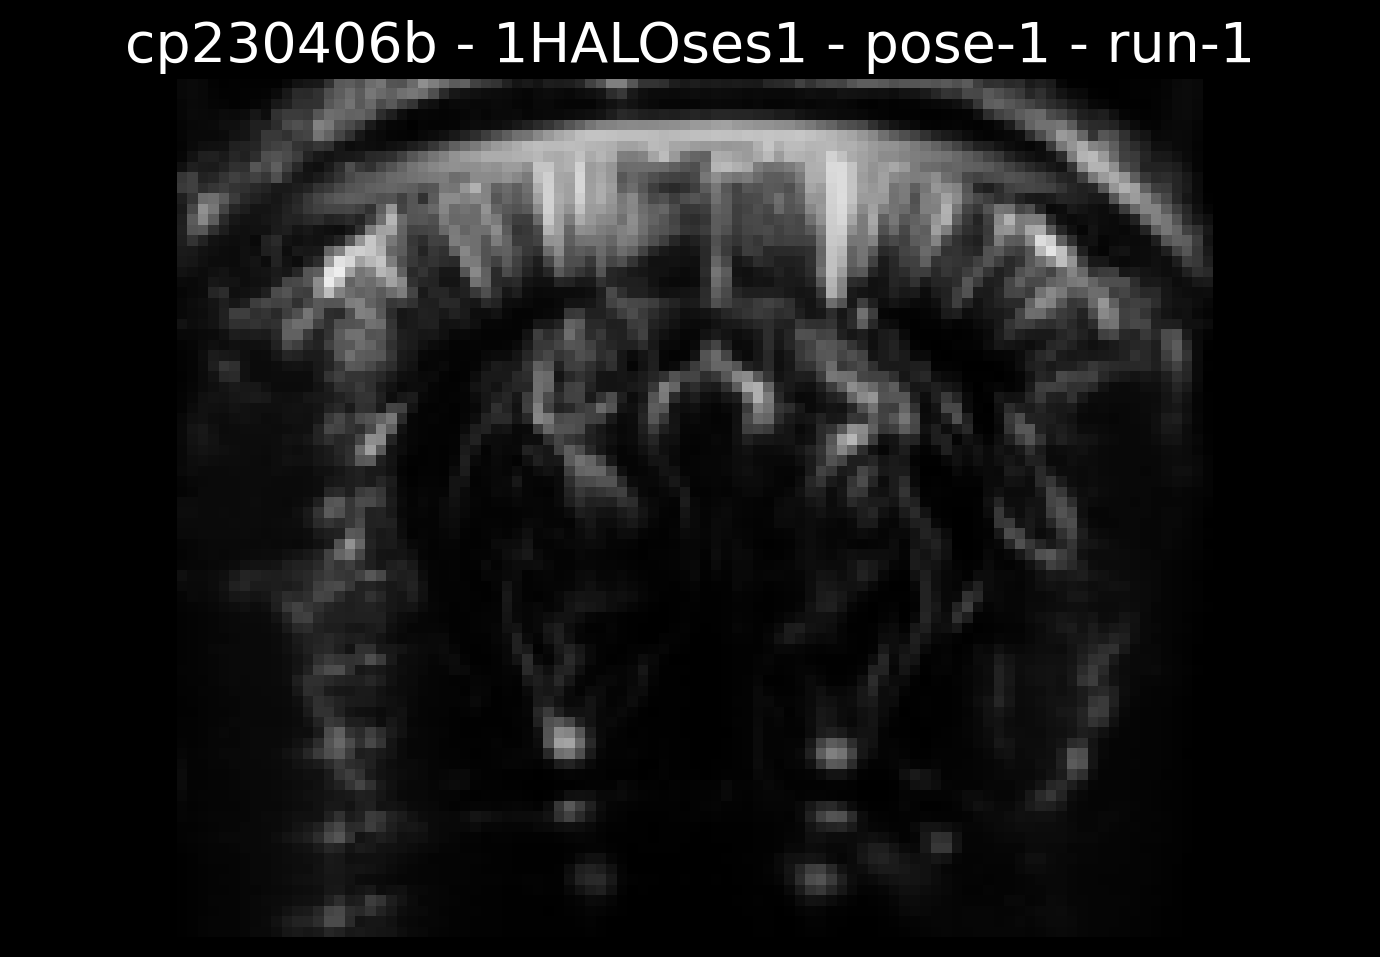

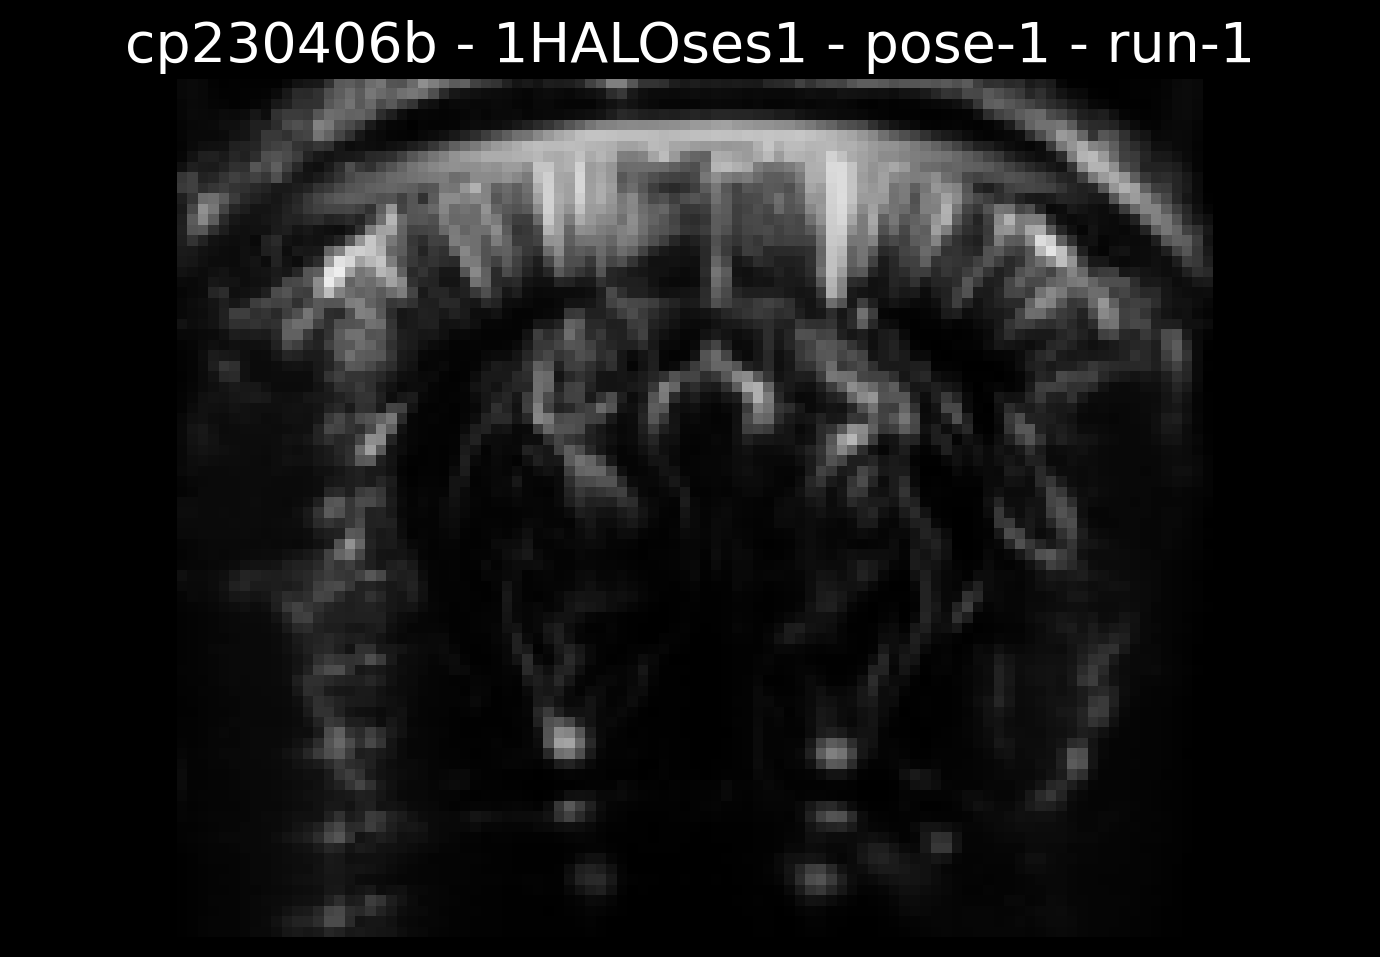

In [30]:
display_avg(nib.load(root_dir[12]), title = title)

In [32]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pose-1.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files:\n\n')

for file_name in root_dir:

    print(f'{file_name.name}')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/trash/visual_SW_display/')

We found 53 files:


sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_task-rest_acq-3Dfus_probe-linear_run-1_pose-1_pwd.nii.gz
sub-cp230406b_ses-1HALO

In [40]:
for pose in range(4):

    print(f'pose-{pose}')

    root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pose-{pose}.*.nii.gz$', x.name)])
    
    for file_name in tqdm(root_dir):
    
        img = nib.load(file_name)
    
        # entities features
        
        subject_name = file_name.name.split('sub-')[1].split('_')[0]
        session_name = file_name.name.split('ses-')[1].split('_')[0]
        pose_id = file_name.name.split('pose-')[1].split('_')[0]
        if 'run' in [x[:3] for x in file_name.name.split('_')]:
            run_id = file_name.name.split('run-')[1].split('_')[0]
        else:
            run_id = '1'
    
        # title and prefix for saving
        
        title = f'{subject_name} - {session_name} - run-{run_id} - pose-{pose_id}'
        prefix = f'sub-{subject_name}_ses-{session_name}_run-{run_id}_pose-{pose_id}'
    
        # display
    
        fig = display_avg(nib.load(file_name), title = title)
        
        # outputs
    
        save_name = save_dir / f'{prefix}_visual.png'
        plt.savefig(save_name)
        plt.close('all')

pose-0


  0%|                                                                                                                 | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_2546493/1538485705.py:5: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().squeeze()[:,:,100:-100].mean(-1))
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [01:00<00:00,  1.13s/it]


pose-1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:49<00:00,  1.07it/s]


pose-2


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:49<00:00,  1.07it/s]


pose-3


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:51<00:00,  1.04it/s]


In [50]:
pose = 3

print(f'pose-{pose}')

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pose-{pose}.*.nii.gz$', x.name)])

[Z,Y,X,T] = img.shape

nb_lin = 11
nb_col = 5

mega_img = np.zeros((nb_lin*Y, nb_col*X))

for i, file_name in tqdm(enumerate(root_dir)):
    
    img = nib.load(file_name)

    img_2_display = np.log10(img.get_fdata().squeeze()[:,:,100:-100].mean(-1))
    img_2_display[np.isinf(img_2_display)] = 0
    img_2_display[np.isnan(img_2_display)] = 0
    
    mega_img[(i//nb_col)*Y:((i//nb_col)+1)*Y, (i%nb_col)*X:((i%nb_col)+1)*X] = img_2_display

pose-3


0it [00:00, ?it/s]/tmp/ipykernel_2546493/1079513146.py:18: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().squeeze()[:,:,100:-100].mean(-1))
53it [00:37,  1.43it/s]


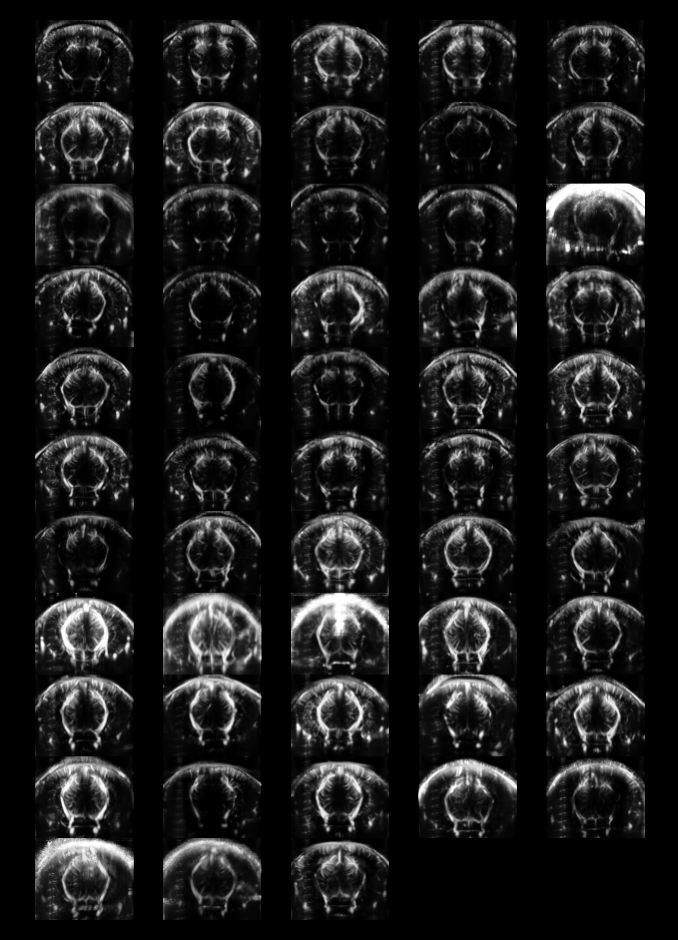

In [51]:
plt.figure(dpi = 200, facecolor = 'k')

plt.imshow(mega_img, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2)
plt.axis('off')

plt.tight_layout()


# End

In [264]:
%history

import re
import shutil

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from time import time

from nilearn.image import math_img
from nipype.interfaces.ants import ApplyTransforms, Registration
from nipype.interfaces.fsl import FLIRT, FNIRT, ApplyWarp, InvWarp
from nipype.interfaces import afni
from scipy.ndimage import binary_fill_holes

# Reportlab for pdf 

from reportlab.pdfbase import pdfmetrics
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas
# Reportlab params for reports

MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Bold.afm', '../../../utils/fonts/montserrat/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Light.afm', '../../../utils/fonts/montserrat/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(Mon